<a href="https://colab.research.google.com/github/SrushtiH23/Task2/blob/main/Task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install opendatasets

In [2]:
import opendatasets as od
import pandas

od.download(
    "https://www.kaggle.com/datasets/yasserh/titanic-dataset")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: SrushtiHosamani23
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/yasserh/titanic-dataset


100%|██████████| 22.0k/22.0k [00:00<00:00, 26.5MB/s]

#Loading Datset

In [7]:
import pandas as pd
df=pd.read_csv('/content/titanic-dataset/Titanic-Dataset.csv')
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


#Data Cleaning

In [8]:
print('Original DataFrame Info:')
df.info()

# 1. Drop irrelevant columns
df_cleaned = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])
print("\nDropped 'PassengerId', 'Name', 'Ticket', and 'Cabin' columns.")

# 2. Handle missing values in 'Age' by filling with the median
median_age = df_cleaned['Age'].median()
df_cleaned['Age'].fillna(median_age, inplace=True)
print(f"Filled missing 'Age' values with median: {median_age}")

# 3. Handle missing values in 'Embarked' by filling with the mode
mode_embarked = df_cleaned['Embarked'].mode()[0]
df_cleaned['Embarked'].fillna(mode_embarked, inplace=True)
print(f"Filled missing 'Embarked' values with mode: {mode_embarked}")

# 4. Display the number of remaining missing values for each column
print('\nRemaining missing values after cleaning:')
print(df_cleaned.isnull().sum())

# 5. Print the concise summary of the cleaned DataFrame
print('\nCleaned DataFrame Info:')
df_cleaned.info()

Original DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Dropped 'PassengerId', 'Name', 'Ticket', and 'Cabin' columns.
Filled missing 'Age' values with median: 28.0
Filled missing 'Embarked' values with mode: S

Remaining missing values after cleaning:
Survived    0
Pclass  

/tmp/ipython-input-331/3096741041.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_cleaned['Age'].fillna(median_age, inplace=True)
/tmp/ipython-input-331/3096741041.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tr

#Exploratory Data Analysis (EDA)

In [9]:
print('Descriptive statistics for numerical columns:')
print(df_cleaned.describe())

Descriptive statistics for numerical columns:
         Survived      Pclass         Age       SibSp       Parch        Fare
count  891.000000  891.000000  891.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.361582    0.523008    0.381594   32.204208
std      0.486592    0.836071   13.019697    1.102743    0.806057   49.693429
min      0.000000    1.000000    0.420000    0.000000    0.000000    0.000000
25%      0.000000    2.000000   22.000000    0.000000    0.000000    7.910400
50%      0.000000    3.000000   28.000000    0.000000    0.000000   14.454200
75%      1.000000    3.000000   35.000000    1.000000    0.000000   31.000000
max      1.000000    3.000000   80.000000    8.000000    6.000000  512.329200


In [10]:
print('\nSurvival rate by Gender:')
print(df_cleaned.groupby('Sex')['Survived'].mean())

print('\nSurvival rate by Pclass:')
print(df_cleaned.groupby('Pclass')['Survived'].mean())

print('\nSurvival rate by Embarked:')
print(df_cleaned.groupby('Embarked')['Survived'].mean())


Survival rate by Gender:
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

Survival rate by Pclass:
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

Survival rate by Embarked:
Embarked
C    0.553571
Q    0.389610
S    0.339009
Name: Survived, dtype: float64


In [11]:
print('\nDescriptive statistics for Age by Survival Status:')
print(df_cleaned.groupby('Survived')['Age'].describe())


Descriptive statistics for Age by Survival Status:
          count       mean        std   min   25%   50%   75%   max
Survived                                                           
0         549.0  30.028233  12.499986  1.00  23.0  28.0  35.0  74.0
1         342.0  28.291433  13.764425  0.42  21.0  28.0  35.0  80.0


In [12]:
print('\nDescriptive statistics for Fare by Survival Status:')
print(df_cleaned.groupby('Survived')['Fare'].describe())


Descriptive statistics for Fare by Survival Status:
          count       mean        std  min      25%   50%   75%       max
Survived                                                                 
0         549.0  22.117887  31.388207  0.0   7.8542  10.5  26.0  263.0000
1         342.0  48.395408  66.596998  0.0  12.4750  26.0  57.0  512.3292


In [13]:
print('Correlation Matrix for Numerical Columns:')
print(df_cleaned.corr(numeric_only=True))

Correlation Matrix for Numerical Columns:
          Survived    Pclass       Age     SibSp     Parch      Fare
Survived  1.000000 -0.338481 -0.064910 -0.035322  0.081629  0.257307
Pclass   -0.338481  1.000000 -0.339898  0.083081  0.018443 -0.549500
Age      -0.064910 -0.339898  1.000000 -0.233296 -0.172482  0.096688
SibSp    -0.035322  0.083081 -0.233296  1.000000  0.414838  0.159651
Parch     0.081629  0.018443 -0.172482  0.414838  1.000000  0.216225
Fare      0.257307 -0.549500  0.096688  0.159651  0.216225  1.000000


#Visualize Key Findings

/tmp/ipython-input-331/275147820.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sex', y='Survived', data=df_cleaned, palette='viridis')
/tmp/ipython-input-331/275147820.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Pclass', y='Survived', data=df_cleaned, palette='viridis')
/tmp/ipython-input-331/275147820.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Embarked', y='Survived', data=df_cleaned, palette='viridis')


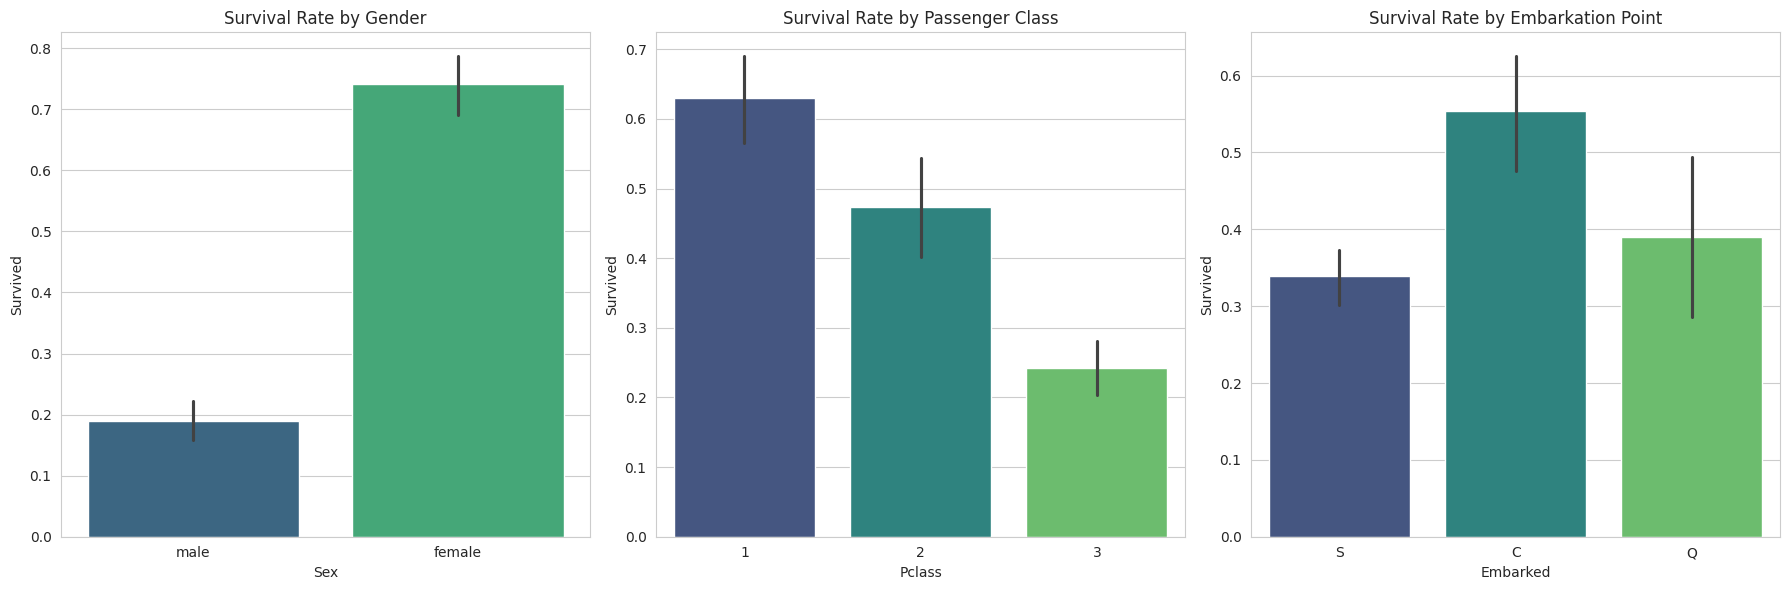

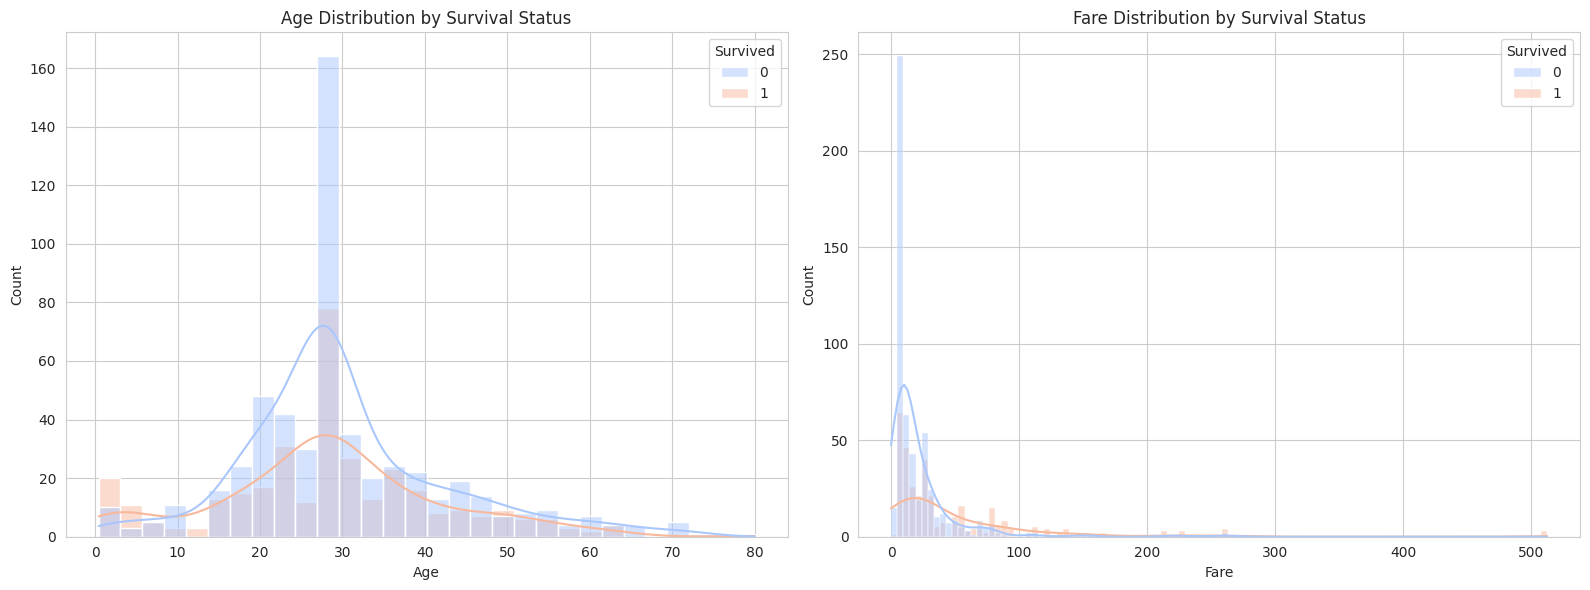

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for plots
sns.set_style('whitegrid')

# Figure 1: Survival Rates by Categorical Features
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
sns.barplot(x='Sex', y='Survived', data=df_cleaned, palette='viridis')
plt.title('Survival Rate by Gender')

plt.subplot(1, 3, 2)
sns.barplot(x='Pclass', y='Survived', data=df_cleaned, palette='viridis')
plt.title('Survival Rate by Passenger Class')

plt.subplot(1, 3, 3)
sns.barplot(x='Embarked', y='Survived', data=df_cleaned, palette='viridis')
plt.title('Survival Rate by Embarkation Point')

plt.tight_layout()
plt.show()

# Figure 2: Age and Fare Distributions by Survival Status
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
sns.histplot(data=df_cleaned, x='Age', hue='Survived', kde=True, palette='coolwarm')
plt.title('Age Distribution by Survival Status')

plt.subplot(1, 2, 2)
sns.histplot(data=df_cleaned, x='Fare', hue='Survived', kde=True, palette='coolwarm')
plt.title('Fare Distribution by Survival Status')

plt.tight_layout()
plt.show()

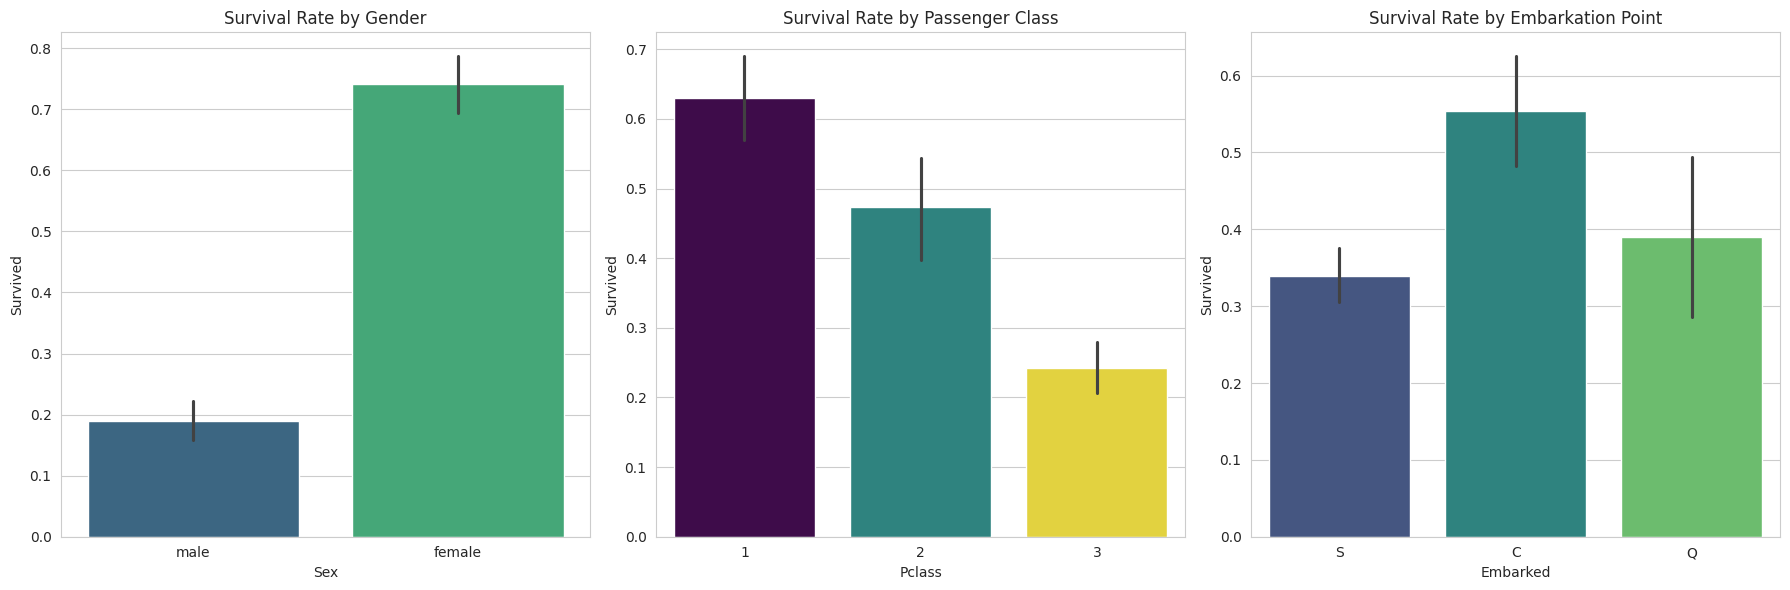

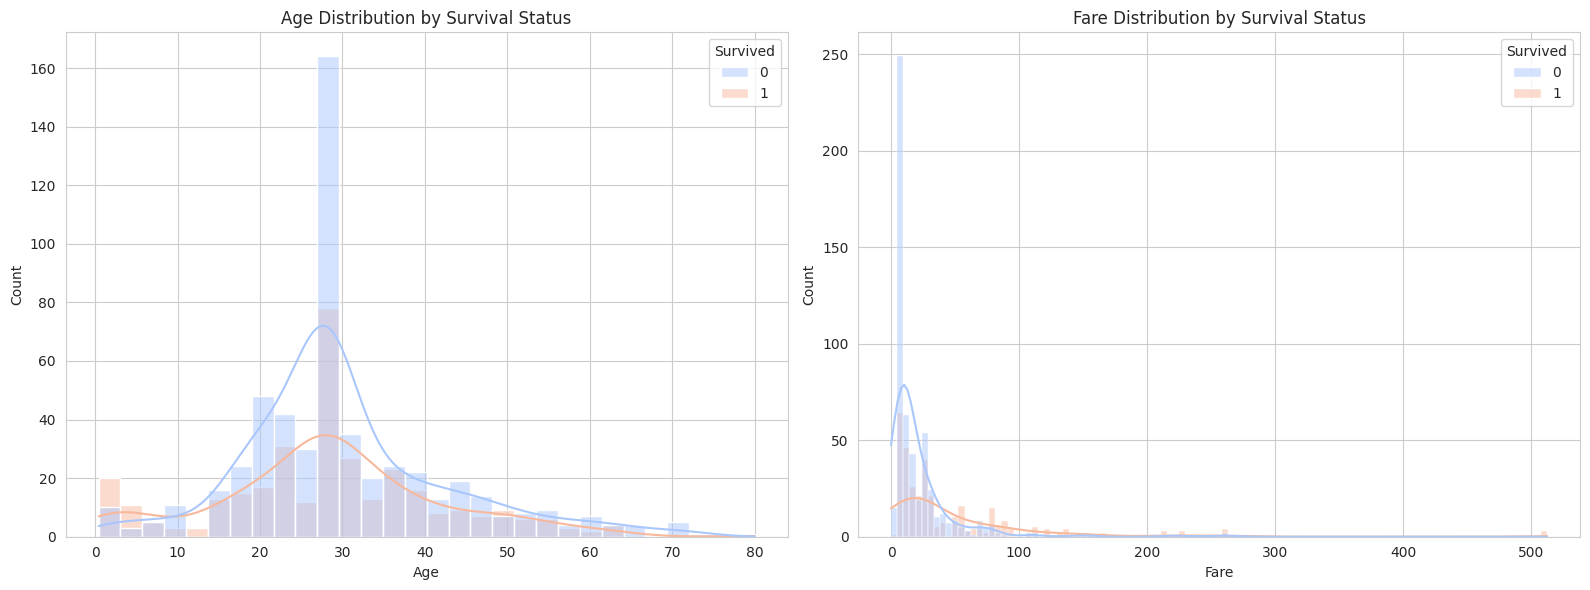

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for plots
sns.set_style('whitegrid')

# Figure 1: Survival Rates by Categorical Features
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
sns.barplot(x='Sex', y='Survived', hue='Sex', data=df_cleaned, palette='viridis', legend=False)
plt.title('Survival Rate by Gender')

plt.subplot(1, 3, 2)
sns.barplot(x='Pclass', y='Survived', hue='Pclass', data=df_cleaned, palette='viridis', legend=False)
plt.title('Survival Rate by Passenger Class')

plt.subplot(1, 3, 3)
sns.barplot(x='Embarked', y='Survived', hue='Embarked', data=df_cleaned, palette='viridis', legend=False)
plt.title('Survival Rate by Embarkation Point')

plt.tight_layout()
plt.show()

# Figure 2: Age and Fare Distributions by Survival Status
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
sns.histplot(data=df_cleaned, x='Age', hue='Survived', kde=True, palette='coolwarm')
plt.title('Age Distribution by Survival Status')

plt.subplot(1, 2, 2)
sns.histplot(data=df_cleaned, x='Fare', hue='Survived', kde=True, palette='coolwarm')
plt.title('Fare Distribution by Survival Status')

plt.tight_layout()
plt.show()